This is an analysis of the *San Francisco Salaries* dataset acquired from the following link at [Kaggle](https://www.kaggle.com/datasets/kaggle/sf-salaries?resource=download).

The data is for San Francisco city employees from 2011-2014. This allows for a comparison in one broad category: how compensation is distributed and how it changed over the four-year period. This encompasses a variety of aspects.

Compensation distribution can refer to the whole government budget and within specific groups or positions. For example, looking at what portion of a position's compensation is overtime, and what portion of the whole budget goes towards IT Workers in general.

In [168]:
import sqlite3 as sql
import pandas as pd
import matplotlib.pyplot as plt

In [169]:
con = sql.connect("Salaries.sqlite")
cur = con.cursor()

In [170]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
cur.execute(query)
tables = cur.fetchall()

In [171]:
columnDict = {}

for i,table in enumerate(tables):
    query = "SELECT * FROM %s;" % table
    cur.execute(query)
    cols = list(cur.description)
    valuelist = []
    for j, col in enumerate(cols):
        collist = list(col)
        valuelist.append(collist[0])
    columnDict[table] = valuelist

columnDict

{('Salaries',): ['Id',
  'EmployeeName',
  'JobTitle',
  'BasePay',
  'OvertimePay',
  'OtherPay',
  'Benefits',
  'TotalPay',
  'TotalPayBenefits',
  'Year',
  'Notes',
  'Agency',
  'Status']}

In [ ]:
columnlabels = ['Job Title'] + valuelist[3:9] + ['Total Wages']
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries where Year='""" + str(year) + """'"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
aWageBudget = df["Total Wages"].to_numpy()

In [173]:
query = """ SELECT DISTINCT Notes from Salaries"""
cur.execute(query)
cur.fetchall()

[('',)]

In [174]:
query = """ SELECT DISTINCT Agency from Salaries"""
cur.execute(query)
cur.fetchall()

[('San Francisco',)]

In [175]:
query = """ SELECT DISTINCT Status from Salaries"""
cur.execute(query)
cur.fetchall()

[('',), ('PT',), ('FT',)]

In [176]:
query = """ SELECT Status, COUNT(Status) from Salaries GROUP By Status"""
cur.execute(query)
cur.fetchall()

[('', 110535), ('FT', 22334), ('PT', 15785)]

In [177]:
query = """SELECT COUNT(DISTINCT JobTitle) from Salaries"""
cur.execute(query)
cur.fetchmany(5)

[(2159,)]

In [178]:
query = """ SELECT DISTINCT Status from Salaries"""
cur.execute(query)
cur.fetchall()

[('',), ('PT',), ('FT',)]

Now I'll being look at the min, max, and average for each pay category, and investigating anything aberrant. 

In [179]:
query = """ SELECT MIN(BasePay), MAX(BasePay), AVG(BasePay) from Salaries where BasePay Not in ('Not Provided','')"""
cur.execute(query)
cur.fetchall()

[(-166.01, 319275.01, 66325.44884048769)]

In [180]:
query = """ SELECT Year, MIN(BasePay), MAX(BasePay), AVG(BasePay) from Salaries where BasePay Not in ('Not Provided','') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0, 294580.02, 63595.95651677314),
 (2012, -166.01, 302578, 65436.40685742262),
 (2013, 15.83, 319275.01, 69630.03021648063),
 (2014, 0, 318835.49, 66564.42192449959)]

In [181]:
query="Select JobTitle,BasePay from Salaries where BasePay < 0"
cur.execute(query)
cur.fetchall()

[('Junior Clerk', -166.01),
 ('Junior Clerk', -121.63),
 ('Junior Clerk', -109.22),
 ('Junior Clerk', -106.6),
 ('Junior Clerk', -101.88),
 ('Junior Clerk', -93.14),
 ('Junior Clerk', -87.38),
 ('Junior Clerk', -75.67),
 ('Junior Clerk', -59.59),
 ('Junior Clerk', -30.58),
 ('Clerk', -9.5)]

In [182]:
query="Select COUNT(JobTitle) from Salaries where JobTitle in ('Junior Clerk')"
cur.execute(query)
cur.fetchall()

[(596,)]

In [183]:
query="Select COUNT(JobTitle) from Salaries where JobTitle in ('Clerk')"
cur.execute(query)
cur.fetchall()

[(764,)]

For whatever reason, a small portion of the junior clerk and clerk base pay is negative.

In [184]:
query = """SELECT MIN(OvertimePay), MAX(OvertimePay), AVG(OvertimePay) from Salaries where OvertimePay Not in ('Not Provided','')"""
cur.execute(query)
cur.fetchall()

[(-0.01, 245131.88, 5066.059886444668)]

In [185]:
query = """SELECT Year, MIN(OvertimePay), MAX(OvertimePay), AVG(OvertimePay) from Salaries where OvertimePay Not in ('Not Provided','') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0, 245131.88, 4531.065428524019),
 (2012, 0, 220909.48, 5023.417824348583),
 (2013, -0.01, 196689.18, 5281.6419797372755),
 (2014, 0, 173547.73, 5401.993737243894)]

In [186]:
query="Select JobTitle,OvertimePay from Salaries where OvertimePay < 0"
cur.execute(query)
cur.fetchall()

[('Senior Eligibility Worker', -0.01)]

In [187]:
query = """ SELECT MIN(OtherPay), MAX(OtherPay), AVG(OtherPay) from Salaries where OtherPay Not in ('Not Provided')"""
cur.execute(query)
cur.fetchall()

[(-7058.59, 400184.25, 3648.767296804574)]

In [188]:
query = """SELECT Year, MIN(OtherPay), MAX(OtherPay), AVG(OtherPay) from Salaries where OtherPay Not in ('Not Provided') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0, 400184.25, 3617.0819259382174),
 (2012, 0, 245999.41, 3653.4375833650656),
 (2013, -7058.59, 202322.37, 3819.969006807424),
 (2014, -618.13, 342802.63, 3505.421250557465)]

In [189]:
query="Select JobTitle,OtherPay from Salaries where OtherPay < 0"
cur.execute(query)
cur.fetchall()

[('IS Business Analyst-Principal', -7058.59),
 ('Custodial Supervisor', -9.6),
 ('Gardener', -46.76),
 ('Special Nurse', -50.19),
 ('Counselor, Log Cabin Ranch', -618.13)]

In [190]:
query = """ SELECT MIN(Benefits), MAX(Benefits), AVG(Benefits) from Salaries where Benefits Not in ('Not Provided','')"""
cur.execute(query)
cur.fetchall()

[(-33.89, 96570.66, 25007.89315082984)]

In [191]:
query = """ SELECT Year, MIN(Benefits), MAX(Benefits), AVG(Benefits) from Salaries where Benefits Not in ('Not Provided','') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2012, 0, 84681.82, 26439.96696730675),
 (2013, -33.89, 86533.21, 23829.07657208956),
 (2014, -13.8, 96570.66, 24789.601756079646)]

In [192]:
query="Select JobTitle,Benefits from Salaries where Benefits < 0"
cur.execute(query)
cur.fetchall()

[('Police Officer 3', -2.73),
 ('Police Officer 3', -8.2),
 ('Police Officer 3', -33.89),
 ('Secretary 2', -13.8)]

In [193]:
query = """ SELECT MIN(TotalPay), MAX(TotalPay), AVG(TotalPay) from Salaries"""
cur.execute(query)
cur.fetchall()

[(-618.13, 567595.43, 74768.32197169265)]

In [194]:
query = """SELECT Year, MIN(TotalPay), MAX(TotalPay), AVG(TotalPay) from Salaries where TotalPay Not in ('Not Provided','') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0, 567595.43, 71744.10387123538),
 (2012, 0, 362844.66, 74113.26226513626),
 (2013, 0, 347102.32, 77611.44314205181),
 (2014, -618.13, 471952.64, 75463.91814023031)]

In [195]:
query="Select JobTitle,TotalPay from Salaries where TotalPay < 0"
cur.execute(query)
cur.fetchall()

[('Counselor, Log Cabin Ranch', -618.13)]

In [196]:
query = """ SELECT MIN(TotalPayBenefits), MAX(TotalPayBenefits), AVG(TotalPayBenefits) from Salaries where TotalPayBenefits Not in ('Not Provided','')"""
cur.execute(query)
cur.fetchall()

[(-618.13, 567595.43, 93692.55481056681)]

In [197]:
query = """ SELECT Year, MIN(TotalPayBenefits), MAX(TotalPayBenefits), AVG(TotalPayBenefits) from Salaries where TotalPayBenefits Not in ('Not Provided','') Group by Year"""
cur.execute(query)
cur.fetchall()

[(2011, 0, 567595.43, 71744.10387123538),
 (2012, 1.91, 407274.78, 100553.22923244302),
 (2013, -33.89, 425815.28, 101440.51971414135),
 (2014, -618.13, 510732.68, 100250.91888361356)]

In [198]:
query="Select JobTitle,TotalPayBenefits from Salaries where TotalPayBenefits < 0"
cur.execute(query)
cur.fetchall()

[('Police Officer 3', -2.73),
 ('Police Officer 3', -8.2),
 ('Police Officer 3', -33.89),
 ('Counselor, Log Cabin Ranch', -618.13)]

# Data Exploration

There are some strange outliers such as jobs with negative base pay that will likely pop up as the exploration and analysis continues. Based on the dataframe, the averages are fairly consistent, except for the glaring 0 benefit average in 2011. In general, 2011 is below average for the different pay categories and by a decent margine (63000 vs 66000 for average base pay). This may be due to budget cuts in 2011 and 2012 as per a [San Francisco Gate Article](https://www.sfgate.com/bayarea/article/Police-staffing-expected-to-shrink-2459144.php#ixzz1Gb2OcXrN), or some other reason.

With the broad strokes established, mainly what possible values there are for each category, the focus can be shifted towards comparing and contrasting different groups of employees. Most of these are curiosities outside of a handful.

The benefits will be looked at over time, as well as the distribution of job titles and if they change in name. Some positions may be renamed and won't be picked up by the **LIKE** command parameters set up. 

I'll be looking at the following:

* **Law Enforcement**: by looking at the strings *Police* and *Sheriff* I can see the Law Enforcement wages paid by the city.
* **Fire Department**: By taking a look at the string *Fire* I can see how much is spent on the Fire Department in terms of wages.
* **Mayor**: by querying 'Mayor' to take a look at the mayor and their staff.
* **Healthcare**: This one is a variety of strings that are cut off to bring in the largest variety of job titles. The list is *nurs* (gets nurse and nursery), *medical*, *health*, *dent*, *pharma* (pharmacy and pharmacist), *Physician*, and *Social Work*. This should get most healthcare workers though with so many strings it will probably get a few incorrect ones which is why I will also try to avoid the strings *resources* and *examiner*. 
* **Information Science**: All of the IT/IS positions start with 'IS' so looking for that with a space afterwards should get all of those positions without having to filter too many other job titles.
* **Justice**: *Defender* should pick up Public Defenders and *court* should pick up most who work at the court. Judge did not seem to get many results which is strange, and even looking for it directly did not give any results aside from a secretary.
* **Engineers and Scientists**: Looking at the strings *bio*, *chem*, *research* and *engineer* should get all the relevant job titles. This is to see how much money is spent on research, development, and engineers in general.
* **Planning**: Looking at the string *plann* should get all job titles related to urban planning.
* **Technicians and Mechanics**: *automotive*, *Electr*, *mech*, *plumb* should get all handymen, mechanics, and technicians. This is to see how much is spent on maintenance work and similar tasks.
* **Clerks**: *clerk* and *secretar* should bring up all clerks, secretaries and other clerical staff to see how much is spent on office staff.

The goal is to get summary statistics (employee count, average pay by type) for each arbitrary department I created and then analyzing it from a broad perspective before honing in on any outliers found.

In [213]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%Police%' OR JobTitle LIKE '%Sheriff%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df["Total Wages"] = df["Total Wages"] / aWageBudget * 100
dfPD = df


In [214]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%Fire%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%Fire%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df["Total Wages"] = df["Total Wages"] / aWageBudget * 100
dfFD = df


In [215]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%Mayor%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%Mayor%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df["Total Wages"] = df["Total Wages"] / aWageBudget * 100
dfMayor = df


In [216]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%nurs%' OR JobTitle LIKE '%medical%' OR JobTitle LIKE '%dent%' OR JobTitle LIKE '%pharma%' 
OR JobTitle LIKE '%physician%' OR JobTitle LIKE '%social work%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%nurs%' OR JobTitle LIKE '%medical%' OR JobTitle LIKE '%dent%' OR JobTitle LIKE '%pharma%' 
OR JobTitle LIKE '%physician%' OR JobTitle LIKE '%social work%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df["Total Wages"] = df["Total Wages"] / aWageBudget * 100
dfHealth = df


In [217]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle Like 'IS %'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits),  SUM(TotalPayBenefits) from Salaries Where (JobTitle Like 'IS %')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df["Total Wages"] = df["Total Wages"] / aWageBudget * 100
dfIS = df


In [225]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits),  SUM(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%defender%' OR JobTitle LIKE '%court%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits),  SUM(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%defender%' OR JobTitle LIKE '%court%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df["Total Wages"] = df["Total Wages"] / aWageBudget * 100
dfJustice = df


In [226]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits),  SUM(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%bio%' OR JobTitle LIKE '%chem%' OR JobTitle LIKE '%research%' OR JobTitle LIKE '%eng%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits),  SUM(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%bio%' OR JobTitle LIKE '%chem%' OR JobTitle LIKE '%research%' OR JobTitle LIKE '%eng%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df["Total Wages"] = df["Total Wages"] / aWageBudget * 100
dfEng = df


In [227]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle Like '%plann%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits), SUM(TotalPayBenefits) from Salaries Where (JobTitle Like '%plann%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df["Total Wages"] = df["Total Wages"] / aWageBudget * 100
dfPlan = df


In [228]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits),  SUM(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%automotive%' OR JobTitle LIKE '%electr%' OR JobTitle LIKE '%mech%' OR JobTitle LIKE '%plumb%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits),  SUM(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%automotive%' OR JobTitle LIKE '%electr%' OR JobTitle LIKE '%mech%' OR JobTitle LIKE '%plumb%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df["Total Wages"] = df["Total Wages"] / aWageBudget * 100
dfTech = df


In [229]:
df= pd.DataFrame()
query = """ SELECT DISTINCT Year from Salaries"""
cur.execute(query)
YearList= [year[0] for year in cur.fetchall()]
for year in YearList:
    query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits),  SUM(TotalPayBenefits) from Salaries where ((Year='"""+ str(year) + """') AND (JobTitle LIKE '%clerk%' OR JobTitle LIKE '%secretar%'))"""
    cur.execute(query)
    if year==2011:
        df=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels, index=[year])
    else:
        df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=[year])    
        df=pd.concat([df,df2],ignore_index=False)

query="""Select COUNT(JobTitle), AVG(BasePay), AVG(OvertimePay), AVG(OtherPay), AVG(Benefits), AVG(TotalPay), AVG(TotalPayBenefits),  SUM(TotalPayBenefits) from Salaries Where (JobTitle LIKE '%clerk%' OR JobTitle LIKE '%secretar%')"""
cur.execute(query)
df2=pd.DataFrame([cur.fetchall()[0]], columns=columnlabels,index=['Whole Period'])    
df=pd.concat([df,df2],ignore_index=False)
df["Total Wages"] = df["Total Wages"] / aWageBudget * 100
dfClerk = df


# Broad Analysis

In this section, I want to compare and contrast the broad patterns I saw in the categories presented and present trends in pay ratios, total wage ratios, and employment numbers.

1. Look at largest and smallest departments I arbitarily created, both in terms of employees and in terms of total pay.
2. Outliers for Overtime Pay ratios, Other Pay etc.
3. Largest change in employees.


## General Summary of Findings

According to the San Francisco Gate Article, 2011 was uniquely hit by budget cuts which can be seen by the lack of benefits in that year and the total pay without benefits being the lowest in that year. Total Pay typically rose around 10% from 2011 to 2012-2014, though the values do fluctuate. For example, in 2011 the Fire Department had an average total pay of around USD$145k which increased to 152k the following year, 160k in 2013, and 148k in 2014.

Benefits range from around $30k to $40k, and typically make up around 30% of total compensation.



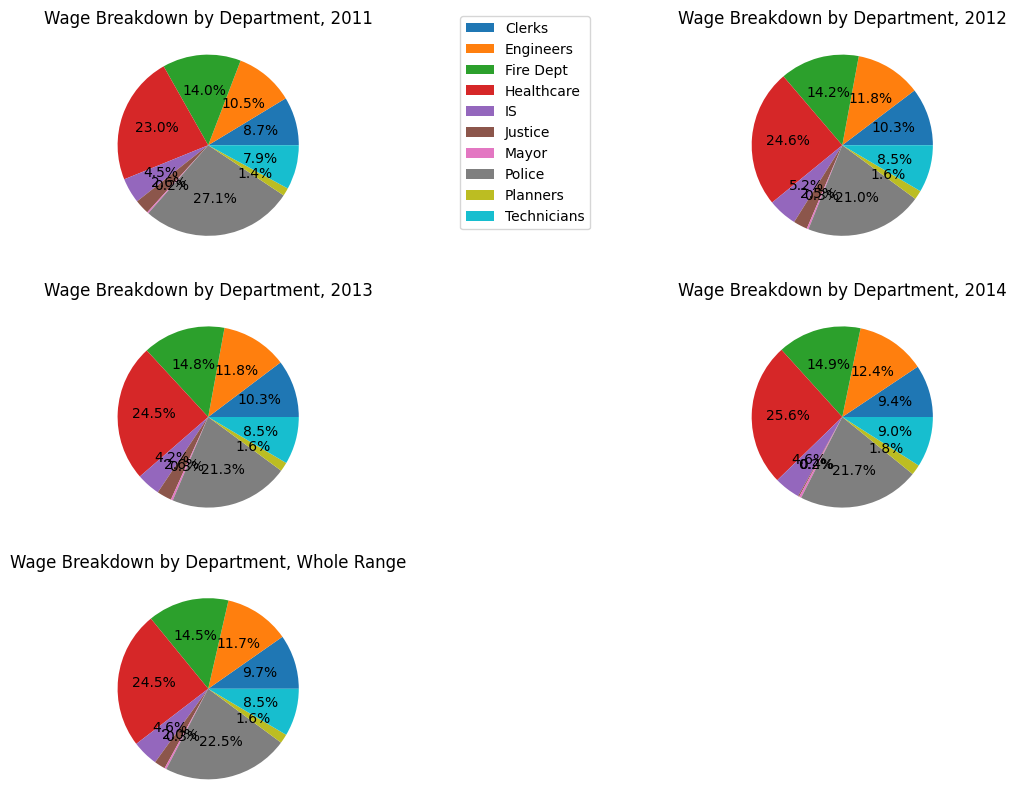

In [230]:
labels=["Clerks","Engineers","Fire Dept","Healthcare","IS","Justice","Mayor","Police","Planners","Technicians"]

Budgets2011= [dfClerk.iloc[0,7],dfEng.iloc[0,7],dfFD.iloc[0,7],dfHealth.iloc[0,7],dfIS.iloc[0,7],dfJustice.iloc[0,7],dfMayor.iloc[0,7],dfPD.iloc[0,7],dfPlan.iloc[0,7],dfTech.iloc[0,7]]
Budgets2012= [dfClerk.iloc[1,7],dfEng.iloc[1,7],dfFD.iloc[1,7],dfHealth.iloc[1,7],dfIS.iloc[1,7],dfJustice.iloc[1,7],dfMayor.iloc[1,7],dfPD.iloc[1,7],dfPlan.iloc[1,7],dfTech.iloc[1,7]]
Budgets2013= [dfClerk.iloc[2,7],dfEng.iloc[2,7],dfFD.iloc[2,7],dfHealth.iloc[2,7],dfIS.iloc[2,7],dfJustice.iloc[2,7],dfMayor.iloc[2,7],dfPD.iloc[2,7],dfPlan.iloc[2,7],dfTech.iloc[2,7]]
Budgets2014= [dfClerk.iloc[3,7],dfEng.iloc[3,7],dfFD.iloc[3,7],dfHealth.iloc[3,7],dfIS.iloc[3,7],dfJustice.iloc[3,7],dfMayor.iloc[3,7],dfPD.iloc[3,7],dfPlan.iloc[3,7],dfTech.iloc[3,7]]
BudgetsTotal= [dfClerk.iloc[4,7],dfEng.iloc[4,7],dfFD.iloc[4,7],dfHealth.iloc[4,7],dfIS.iloc[4,7],dfJustice.iloc[4,7],dfMayor.iloc[4,7],dfPD.iloc[4,7],dfPlan.iloc[4,7],dfTech.iloc[4,7]]

fig, ax =plt.subplots(nrows=3,ncols=2, figsize=(15,10))
fig.delaxes(ax[2,1])

ax[0,0].pie(Budgets2011,autopct='%1.1f%%')
ax[0,0].set_title('Wage Breakdown by Department, 2011')
ax[0,1].pie(Budgets2012,autopct='%1.1f%%')
ax[0,1].set_title('Wage Breakdown by Department, 2012')
ax[1,0].pie(Budgets2013,autopct='%1.1f%%')
ax[1,0].set_title('Wage Breakdown by Department, 2013')
ax[1,1].pie(Budgets2014,autopct='%1.1f%%')
ax[1,1].set_title('Wage Breakdown by Department, 2014')
ax[2,0].pie(BudgetsTotal,autopct='%1.1f%%')
ax[2,0].set_title('Wage Breakdown by Department, Whole Range')
plt.legend(labels=labels,loc="center",bbox_to_anchor=(1.9,3))

Text(0.5, 1.0, 'Employment Count by Department')

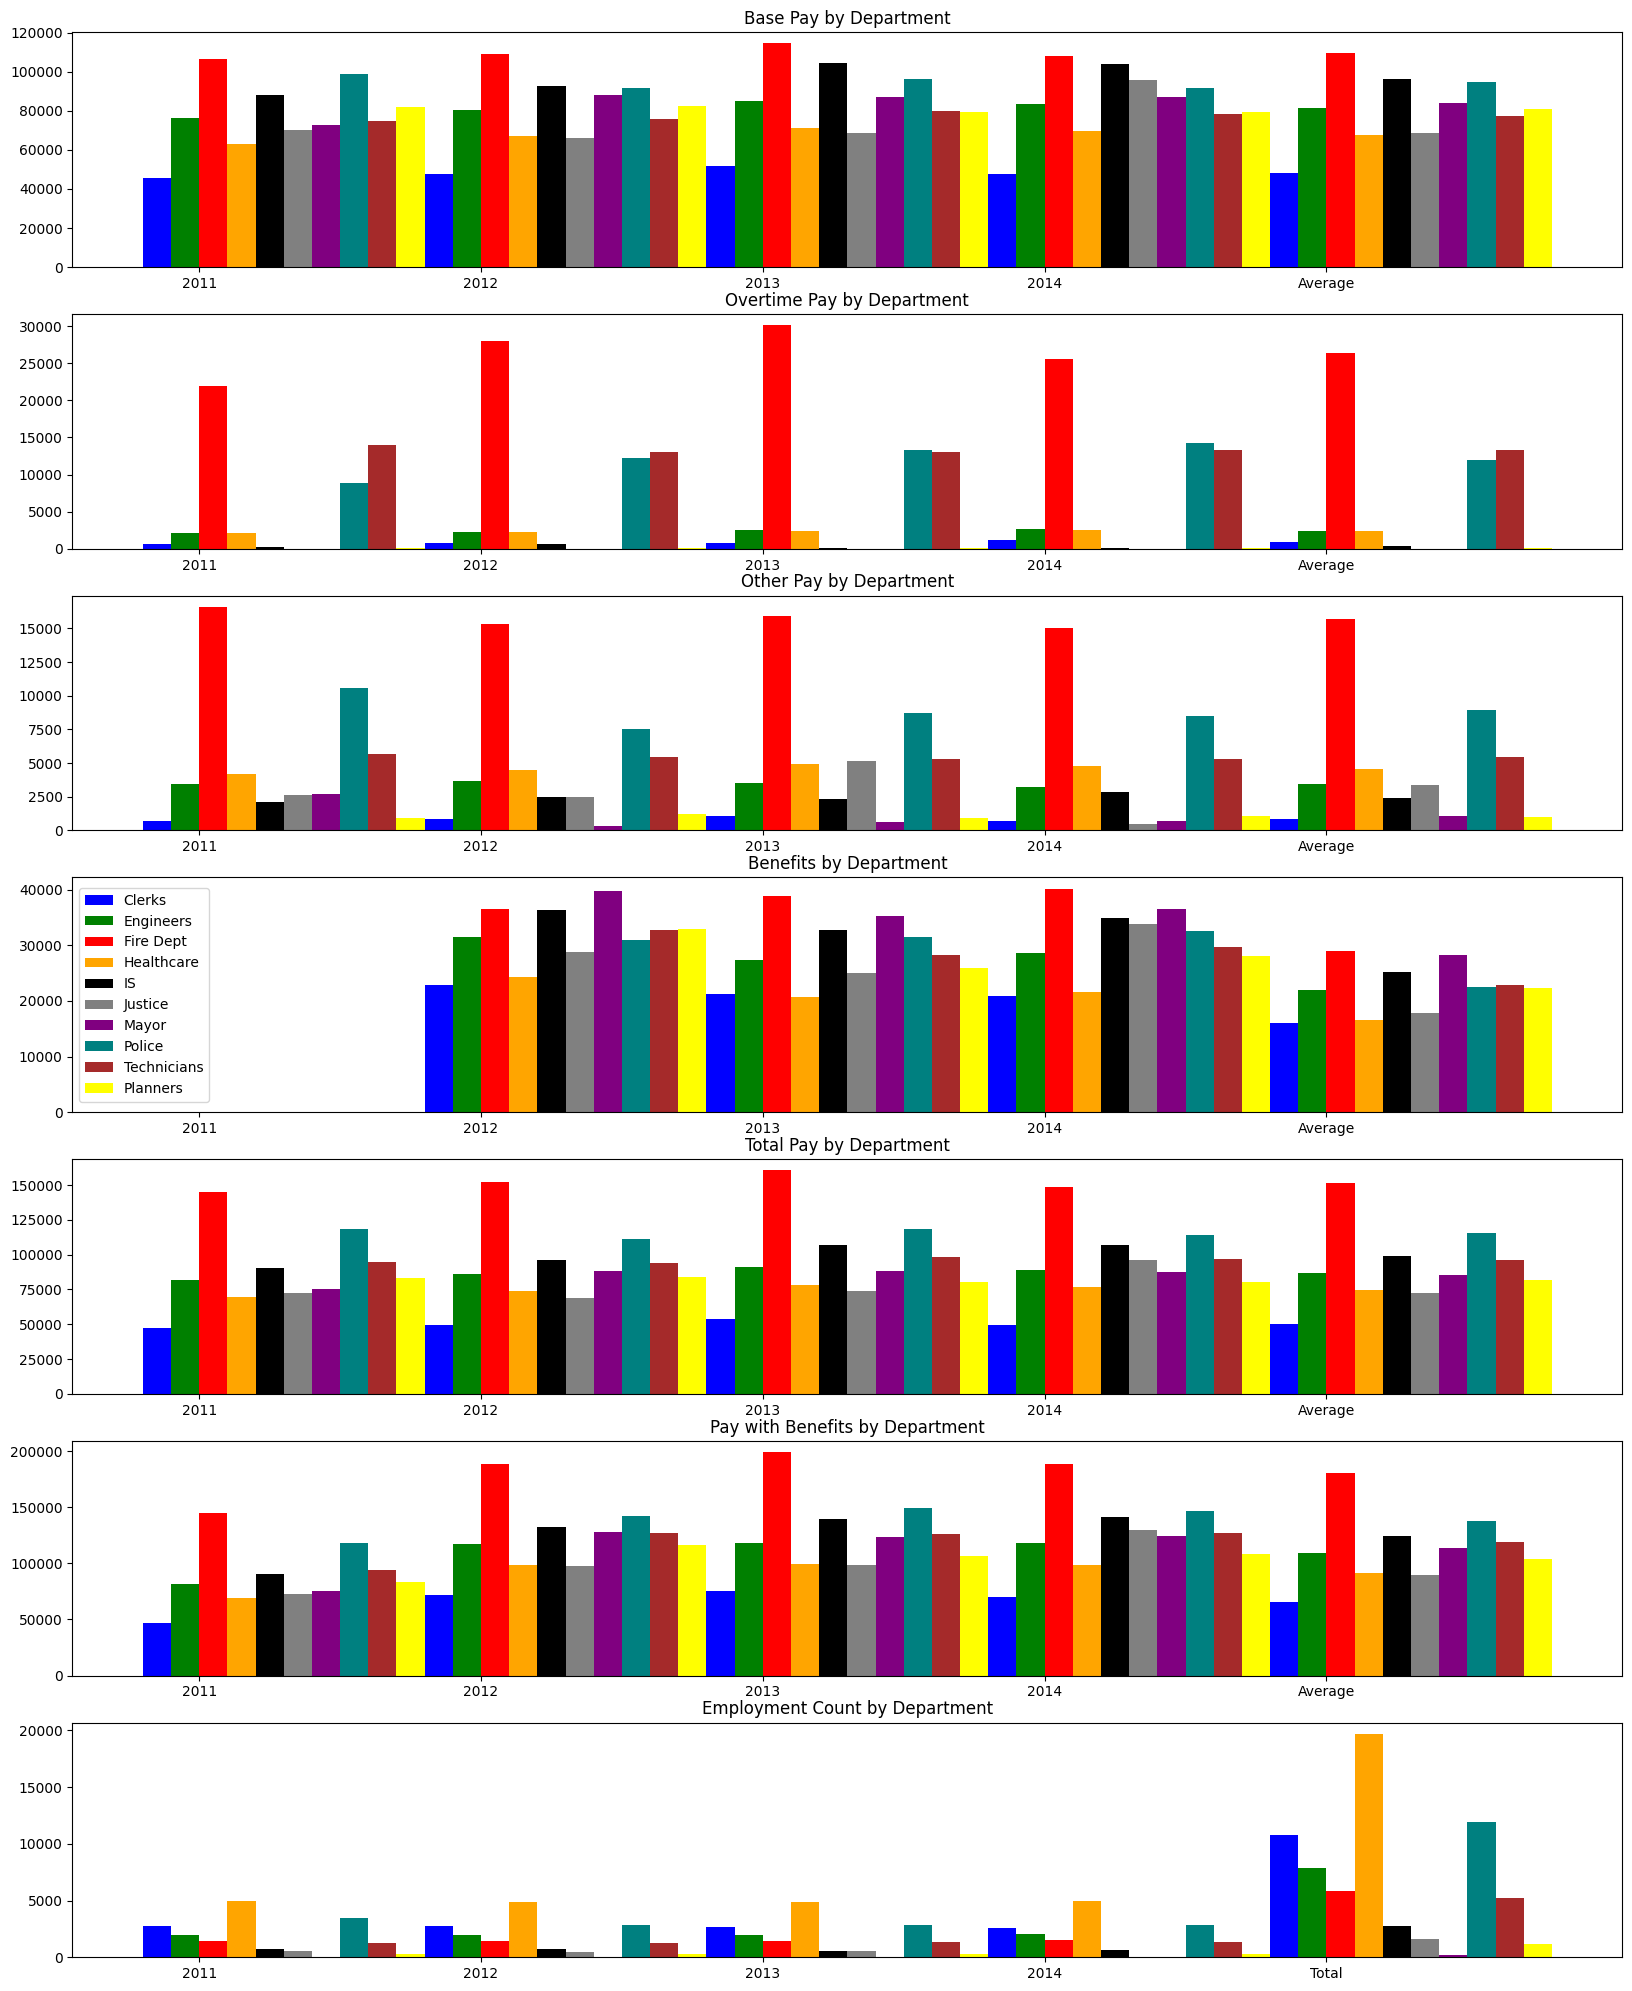

In [233]:
import numpy as np
fig, (ax1,ax2,ax3,ax4,ax5,ax6,ax7) = plt.subplots(nrows = 7, ncols=1, figsize=(20,25))
multiplebars = np.arange(5)
width=0.1
XAxisLabels = ['2011', '2012', '2013', '2014', 'Average']

ax1.set_xticks(multiplebars + 1.5 * width, XAxisLabels)
ax1.bar(multiplebars, dfClerk["BasePay"], width, color='b', label='Clerks')
ax1.bar(multiplebars + width, dfEng["BasePay"], width, color='g', label='Engineers')
ax1.bar(multiplebars + 2 * width, dfFD["BasePay"], width, color='r', label='Fire Dept')
ax1.bar(multiplebars + 3 * width, dfHealth["BasePay"], width, color='orange', label='Healthcare')
ax1.bar(multiplebars + 4 * width, dfIS["BasePay"], width, color='black', label='IS')
ax1.bar(multiplebars + 5 * width, dfJustice["BasePay"], width, color='gray', label='Justice')
ax1.bar(multiplebars + 6 * width, dfMayor["BasePay"], width, color='purple', label='Mayor')
ax1.bar(multiplebars + 7 * width, dfPD["BasePay"], width, color='teal', label='Police')
ax1.bar(multiplebars + 8 * width, dfTech["BasePay"], width, color='brown', label='Technicians')
ax1.bar(multiplebars + 9 * width, dfPlan["BasePay"], width, color='yellow', label='Planners')
ax1.set_title("Base Pay by Department")

ax2.set_xticks(multiplebars + 1.5 * width, XAxisLabels)
ax2.bar(multiplebars, dfClerk["OvertimePay"], width, color='b', label='Clerks')
ax2.bar(multiplebars + width, dfEng["OvertimePay"], width, color='g', label='Engineers')
ax2.bar(multiplebars + 2 * width, dfFD["OvertimePay"], width, color='r', label='Fire Dept')
ax2.bar(multiplebars + 3 * width, dfHealth["OvertimePay"], width, color='orange', label='Healthcare')
ax2.bar(multiplebars + 4 * width, dfIS["OvertimePay"], width, color='black', label='IS')
ax2.bar(multiplebars + 5 * width, dfJustice["OvertimePay"], width, color='gray', label='Justice')
ax2.bar(multiplebars + 6 * width, dfMayor["OvertimePay"], width, color='purple', label='Mayor')
ax2.bar(multiplebars + 7 * width, dfPD["OvertimePay"], width, color='teal', label='Police')
ax2.bar(multiplebars + 8 * width, dfTech["OvertimePay"], width, color='brown', label='Technicians')
ax2.bar(multiplebars + 9 * width, dfPlan["OvertimePay"], width, color='yellow', label='Planners')
ax2.set_title("Overtime Pay by Department")

ax3.set_xticks(multiplebars + 1.5 * width, XAxisLabels)
ax3.bar(multiplebars, dfClerk["OtherPay"], width, color='b', label='Clerks')
ax3.bar(multiplebars + width, dfEng["OtherPay"], width, color='g', label='Engineers')
ax3.bar(multiplebars + 2 * width, dfFD["OtherPay"], width, color='r', label='Fire Dept')
ax3.bar(multiplebars + 3 * width, dfHealth["OtherPay"], width, color='orange', label='Healthcare')
ax3.bar(multiplebars + 4 * width, dfIS["OtherPay"], width, color='black', label='IS')
ax3.bar(multiplebars + 5 * width, dfJustice["OtherPay"], width, color='gray', label='Justice')
ax3.bar(multiplebars + 6 * width, dfMayor["OtherPay"], width, color='purple', label='Mayor')
ax3.bar(multiplebars + 7 * width, dfPD["OtherPay"], width, color='teal', label='Police')
ax3.bar(multiplebars + 8 * width, dfTech["OtherPay"], width, color='brown', label='Technicians')
ax3.bar(multiplebars + 9 * width, dfPlan["OtherPay"], width, color='yellow', label='Planners')
ax3.set_title("Other Pay by Department")

ax4.set_xticks(multiplebars + 1.5 * width, XAxisLabels)
ax4.bar(multiplebars, dfClerk["Benefits"], width, color='b', label='Clerks')
ax4.bar(multiplebars + width, dfEng["Benefits"], width, color='g', label='Engineers')
ax4.bar(multiplebars + 2 * width, dfFD["Benefits"], width, color='r', label='Fire Dept')
ax4.bar(multiplebars + 3 * width, dfHealth["Benefits"], width, color='orange', label='Healthcare')
ax4.bar(multiplebars + 4 * width, dfIS["Benefits"], width, color='black', label='IS')
ax4.bar(multiplebars + 5 * width, dfJustice["Benefits"], width, color='gray', label='Justice')
ax4.bar(multiplebars + 6 * width, dfMayor["Benefits"], width, color='purple', label='Mayor')
ax4.bar(multiplebars + 7 * width, dfPD["Benefits"], width, color='teal', label='Police')
ax4.bar(multiplebars + 8 * width, dfTech["Benefits"], width, color='brown', label='Technicians')
ax4.bar(multiplebars + 9 * width, dfPlan["Benefits"], width, color='yellow', label='Planners')
ax4.set_title("Benefits by Department")
ax4.legend(loc='center left')

ax5.set_xticks(multiplebars + 1.5 * width, XAxisLabels)
ax5.bar(multiplebars, dfClerk["TotalPay"], width, color='b', label='Clerks')
ax5.bar(multiplebars + width, dfEng["TotalPay"], width, color='g', label='Engineers')
ax5.bar(multiplebars + 2 * width, dfFD["TotalPay"], width, color='r', label='Fire Dept')
ax5.bar(multiplebars + 3 * width, dfHealth["TotalPay"], width, color='orange', label='Healthcare')
ax5.bar(multiplebars + 4 * width, dfIS["TotalPay"], width, color='black', label='IS')
ax5.bar(multiplebars + 5 * width, dfJustice["TotalPay"], width, color='gray', label='Justice')
ax5.bar(multiplebars + 6 * width, dfMayor["TotalPay"], width, color='purple', label='Mayor')
ax5.bar(multiplebars + 7 * width, dfPD["TotalPay"], width, color='teal', label='Police')
ax5.bar(multiplebars + 8 * width, dfTech["TotalPay"], width, color='brown', label='Technicians')
ax5.bar(multiplebars + 9 * width, dfPlan["TotalPay"], width, color='yellow', label='Planners')
ax5.set_title("Total Pay by Department")

ax6.set_xticks(multiplebars + 1.5 * width, XAxisLabels)
ax6.bar(multiplebars, dfClerk["TotalPayBenefits"], width, color='b', label='Clerks')
ax6.bar(multiplebars + width, dfEng["TotalPayBenefits"], width, color='g', label='Engineers')
ax6.bar(multiplebars + 2 * width, dfFD["TotalPayBenefits"], width, color='r', label='Fire Dept')
ax6.bar(multiplebars + 3 * width, dfHealth["TotalPayBenefits"], width, color='orange', label='Healthcare')
ax6.bar(multiplebars + 4 * width, dfIS["TotalPayBenefits"], width, color='black', label='IS')
ax6.bar(multiplebars + 5 * width, dfJustice["TotalPayBenefits"], width, color='gray', label='Justice')
ax6.bar(multiplebars + 6 * width, dfMayor["TotalPayBenefits"], width, color='purple', label='Mayor')
ax6.bar(multiplebars + 7 * width, dfPD["TotalPayBenefits"], width, color='teal', label='Police')
ax6.bar(multiplebars + 8 * width, dfTech["TotalPayBenefits"], width, color='brown', label='Technicians')
ax6.bar(multiplebars + 9 * width, dfPlan["TotalPayBenefits"], width, color='yellow', label='Planners')
ax6.set_title("Pay with Benefits by Department")

ax7.set_xticks(multiplebars + 1.5 * width, ['2011', '2012', '2013', '2014', 'Total'])
ax7.bar(multiplebars, dfClerk["Job Title"], width, color='b', label='Clerks')
ax7.bar(multiplebars + width, dfEng["Job Title"], width, color='g', label='Engineers')
ax7.bar(multiplebars + 2 * width, dfFD["Job Title"], width, color='r', label='Fire Dept')
ax7.bar(multiplebars + 3 * width, dfHealth["Job Title"], width, color='orange', label='Healthcare')
ax7.bar(multiplebars + 4 * width, dfIS["Job Title"], width, color='black', label='IS')
ax7.bar(multiplebars + 5 * width, dfJustice["Job Title"], width, color='gray', label='Justice')
ax7.bar(multiplebars + 6 * width, dfMayor["Job Title"], width, color='purple', label='Mayor')
ax7.bar(multiplebars + 7 * width, dfPD["Job Title"], width, color='teal', label='Police')
ax7.bar(multiplebars + 8 * width, dfTech["Job Title"], width, color='brown', label='Technicians')
ax7.bar(multiplebars + 9 * width, dfPlan["Job Title"], width, color='yellow', label='Planners')
ax7.set_title("Employment Count by Department")


## Analysis

The Departments can be categorized into three groups:

1. Large: Police and Healthcare - both are towards the top for wages and employee count
2. Nedium: Fire Department, Engineers, Clerks, and Technicians - these have wage budgets that go from around 8 to 15% of the total, and have employee counts which range from around 5 to 10 or so thousand over the four years.
3. Small: IS, Justice, Mayor, and Planners - low employee counts (less than 2500 or so over the four years), and small budgets which range from 0 to 5% of the total wage budget surveyed.

The Fire4 Department does teeter on the edge of medium and large mainly because of its signficantly higher wage budget than other medium departments, though clerks and engineers both have large employee counts (similar to the police department), with a much smaller budget than the police department. On the other hand, Technicians do fit confortably in the medium category as its budget is similar to clerks but its employee count is similar to the Fire Department.

Interestingly the Small departments do contain the Mayoral staff (which is comparitively tiny to the others), which is an outlier in many regards.

### Graph Trends

The most obvious and notable aspect is the lack of benefits in 2011, which is explained by the afforementioned SF Gate article.

I also noticed that the Fire Department is the most well paid department overall, and has a massive lead in both overtime and oher pay when compared to the other departments. Additionally, it has a slightly higher amount of benefits than the other departments. The Police and Technicians also have deent amounts of overtime and other pay but it's around half of the Fire Departments' numbers. 

Base Pay is fairly consistent within departments and ranges from 40,000 to 120,000. There are outliers, such as the Justice, IS and Mayoral Staff varying quite a bit year to year, but these are all small departments which can be sensitive to outliers, such as senior staff retiring or leaving, and junior staff joining or leaving.

Overtime Pay is basically nonexistent aside from the Fire Department, Police Department, and Technicians who take the lion's share of it, per capita, out of the ten departments created. The Fire Department takes on average 20 to 30 thousand in overtime pay per employee, while the Police and Technicians take around 10 to 15 thousand per year per employee. Otherwise, Overtime Pay ranges around a few thousand per employee to functionally zero.

Other Pay has a similar trend to Overtime Pay, though everything has a tighter spread for the data since the Fire Department sits at 15 thousand instead of 20 to 30 thousand. The Police have the second highest Other Pay compensation hovering from 7500 to 10000, and Technicians have the third highest Other Pay compensation but it is much closer to the lower ranked departmetns than in the previous case, with it sitting it around 5000. The Other Departments have similar compensation as the previous example, sitting at around 2 to 4 thousand.

Benefits, as stated before don't exist in 2011, but from 2012 onwards it can be seen to be around 30,000 regardless of department, though there are exceptions. Clerk and Healthcare workers trend towards the low end of the benefits range at around 20 thousand, and Mayoral Staff, IS and the Fire Department getting closer to 40,000 but the numbers for most departments are around the same. 

In fact, this is why the Total Pay and Total Pay with Benefits graphs look basically the same. There are differences, of course, such as Mayotal Staff being relatively closer to the maximum compensation when benefits are added. Regardless, the Total Pay graph broadly follows the Base Pay graph because Overtime and Other Pay are small portions of total compensation overall, and don't contribute much outside of the top three departments. Both Overtime and Other Pay would be insignificant compared to around 30,000 in benefits for most departments. Thus, Base Pay, Total Pay, and Total Pay with Benefits are effectively the same graphs. 